In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel(r"D:\git\python-data-analysis-lab\datasets\resturant.xlsx")
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [3]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [4]:
df.drop('url',inplace=True,axis=1)

In [5]:
df.isna().sum()

address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [6]:
df['name'].iloc[4]

'Grand Village'

In [7]:
df['name'].iloc[[10,1756]]

10      CafÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ© Down The A...
1756     E2 - EntrÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ©e Envoy
Name: name, dtype: object

In [8]:
df['name'].iloc[1:20]

1                                        Spice Elephant
2                                       San Churro Cafe
3                                 Addhuri Udupi Bhojana
4                                         Grand Village
5                                       Timepass Dinner
6       Rosewood International Hotel - Bar & Restaurant
7                                                Onesta
8                                        Penthouse Cafe
9                                             Smacznego
10    CafÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ© Down The A...
11                                         Cafe Shuffle
12                                     The Coffee Shack
13                                           Caf-Eleven
14                                      San Churro Cafe
15                                        Cafe Vivacity
16                                         Catch-up-ino
17                                     Kirthi's Biryani
18                                             T

In [10]:
import re
def clean_names(name):
    if isinstance(name, str):
        
        r = re.compile("[A-Za-z0-9\s]")
        l = re.findall(r,name)
        #return l
        j = "".join(l)
        return j
    else:
        return name
    
# Keep only: r = re.compile("[A-Za-z0-9\s]")

# A-Z     capital letters
# a-z     small letters
# 0-9     numbers
# \s      spaces

# So this pattern allows only:

# letters + numbers + spaces

#------------------------------
# l = re.findall(r, name)

# means:

# Find all allowed letters/numbers/spaces from the name and store them in a list.
# Find all characters in name that match the regex pattern r, and store them in list l.
        

In [11]:
res = clean_names("CafÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ© Down The A...")
print(res)

Caf Down The A


In [12]:
res=clean_names("E2 - EntrÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ©e Envoy")
res

'E2  Entre Envoy'

In [13]:
df.columns

Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [14]:
df.rename(columns={'reviews_list':'rating'}, inplace =True)

In [15]:
df['name']= df['name'].apply(clean_names)

In [16]:
df['name'].iloc[[10,1756]]

10      Caf Down The Alley
1756       E2  Entre Envoy
Name: name, dtype: object

In [17]:
df['rate'].value_counts()

NEW       2208
3.9/5     2098
3.8/5     2022
3.7/5     2011
3.9 /5    1874
          ... 
2.2 /5       7
2.0 /5       7
2.0/5        4
1.8 /5       3
1.8/5        2
Name: rate, Length: 64, dtype: int64

In [18]:
df['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', nan, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '-', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5',
       '2.1 /5', '2.2 /5', '2.0 /5', '1.8 /5'], dtype=object)

In [19]:
s='4.1/5'
s=s.split("/")[0]
s= float(s)
s

4.1

In [20]:
def clean_rate(rate):
    if rate == 'NEW' or rate == '-':
        return np.nan
    else:
        converted_rates = float(str(rate).split("/")[0])
        return converted_rates

In [21]:
res = clean_rate('4.1/5')
res

4.1

In [22]:
res = clean_rate('NEW')
res

nan

In [23]:
df['rate'] = df['rate'].apply(clean_rate)

In [24]:
df['rate'].isna().sum()

10052

In [25]:
df['rate'].mean()

3.700448817952718

In [26]:
df['rate'].fillna(round(df['rate'].mean(),1), inplace=True)
# df['rate'].fillna(round(df['rate'].mean(),1), inplace=True)

In [27]:
df.isna().sum()

address                            0
name                               0
online_order                       0
book_table                         0
rate                               0
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
rating                             0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [28]:
df['approx_cost(for two people)'].fillna(round(df['approx_cost(for two people)'].mean(),0), inplace =True)

In [29]:
df['rest_type'] = df['rest_type'].replace(np.nan,"")

In [30]:
df['cuisines'] = df['cuisines'].replace(np.nan,"")

In [31]:
df.isna().sum()

address                            0
name                               0
online_order                       0
book_table                         0
rate                               0
votes                              0
phone                           1208
location                          21
rest_type                          0
dish_liked                     28078
cuisines                           0
approx_cost(for two people)        0
rating                             0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [32]:
df[df['location'].isnull()]

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),rating,menu_item,listed_in(type),listed_in(city)
1662,"6, Abbiah Layout KC Halli Main Road, Bommanaha...",Papa Khan Rasoi,No,No,3.7,0,NaN,NaN,,NaN,,555.0,[],[],Delivery,Bannerghatta Road
9874,"6, Abbiah Layout KC Halli Main Road, Bommanaha...",Papa Khan Rasoi,No,No,3.7,0,NaN,NaN,,NaN,,555.0,[],[],Delivery,BTM
13693,"Chandapura- Anakal Main Road, Oppsite Vemana H...",Mohabbat Desi Restaurant,No,No,3.7,0,NaN,NaN,,NaN,,555.0,[],[],Delivery,Electronic City
16351,"Kudlu Gate, Bommanahalli, Bangalore",Desi Chatkara,No,No,3.7,0,NaN,NaN,,NaN,,555.0,[],[],Delivery,HSR
26432,"IB Road, Lorry Stand, Kushaal Nagar, Ward 10, ...",New Taj Biryani Centre,No,No,3.7,0,NaN,NaN,,NaN,,555.0,[],[],Dine-out,Kammanahalli
26519,"Koramangala 8th Block, Bangalore",ABs Absolute Barbecues,No,No,3.7,0,NaN,NaN,,NaN,,555.0,[],[],Buffet,Koramangala 4th Block
27672,"6, Kathalipalya Village, 6th Cross, Koramangal...",Manchow,No,No,3.7,0,NaN,NaN,,NaN,,555.0,[],[],Delivery,Koramangala 4th Block
28611,"6, Kathalipalya Village, 6th Cross, Koramangal...",Manchow,No,No,3.7,0,NaN,NaN,,NaN,,555.0,[],[],Dine-out,Koramangala 4th Block
29298,"Koramangala 8th Block, Bangalore",ABs Absolute Barbecues,No,No,3.7,0,NaN,NaN,,NaN,,555.0,[],[],Buffet,Koramangala 5th Block
30604,"6, Kathalipalya Village, 6th Cross, Koramangal...",Manchow,No,No,3.7,0,NaN,NaN,,NaN,,555.0,[],[],Delivery,Koramangala 5th Block


In [33]:
df['location'] = df['location'].replace(np.nan, "")

In [34]:
df.isna().sum()

address                            0
name                               0
online_order                       0
book_table                         0
rate                               0
votes                              0
phone                           1208
location                           0
rest_type                          0
dish_liked                     28078
cuisines                           0
approx_cost(for two people)        0
rating                             0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [35]:
df.drop(["address","listed_in(type)"],inplace=True, axis=1)

In [36]:
df.rename(columns={"phone":"contact"},inplace=True)

In [37]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes', 'contact',
       'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'rating', 'menu_item',
       'listed_in(city)'],
      dtype='object')

In [38]:
df['name'].unique()

array(['Jalsa', 'Spice Elephant', 'San Churro Cafe', ..., 'Nawabs Empire',
       'SeeYa Restaurant',
       'Plunge  Sheraton Grand Bengaluru Whitefield Hotel '], dtype=object)

In [39]:
len(df['name'].unique())

8741

In [40]:
df.groupby('name')[['votes']].mean().sort_values(by='votes',ascending=False).head(10).reset_index()

,name,votes
0,Byg Brewski Brewing Company,16588.500000
1,Toit,14956.000000
2,The Black Pearl,9562.333333
3,Big Pitcher,9164.500000
4,Arbor Brewing Company,8396.545455
5,Prost Brew Pub,7860.900000
6,Church Street Social,7561.727273
7,Hoot,7257.000000
8,The Hole in the Wall Cafe,7124.875000
9,Truffles,7001.372093


In [41]:
top_10_votes = df.groupby('name')[['votes']].mean().sort_values(by='votes',ascending=False).head(10)
top_10_votes = round(top_10_votes,2)
top_10_votes

,votes
name,
Byg Brewski Brewing Company,16588.50
Toit,14956.00
The Black Pearl,9562.33
Big Pitcher,9164.50
Arbor Brewing Company,8396.55
Prost Brew Pub,7860.90
Church Street Social,7561.73
Hoot,7257.00
The Hole in the Wall Cafe,7124.88


In [42]:
df['rating']

0        [('Rated 4.0', 'RATED\n  A beautiful place to ...
1        [('Rated 4.0', 'RATED\n  Had been here for din...
2        [('Rated 3.0', "RATED\n  Ambience is not that ...
3        [('Rated 4.0', "RATED\n  Great food and proper...
4        [('Rated 4.0', 'RATED\n  Very good restaurant ...
                               ...                        
51712    [('Rated 5.0', "RATED\n  Food and service are ...
51713                                                   []
51714                                                   []
51715    [('Rated 4.0', 'RATED\n  Nice and friendly pla...
51716    [('Rated 5.0', 'RATED\n  Great ambience , look...
Name: rating, Length: 51717, dtype: object

In [43]:
df.drop(['rating','menu_item'],inplace=True,axis=1)

In [44]:
top_10_by_rate= df.groupby('name')[['rate']].mean().sort_values(by='rate',ascending=False).head(10)
print(round(top_10_by_rate,2))

                                rate
name                                
Sant Spa Cuisine                4.90
Byg Brewski Brewing Company     4.90
Asia Kitchen By Mainland China  4.90
Punjab Grill                    4.87
Belgian Waffle Factory          4.84
OG Variar  Sons                 4.80
Flechazo                        4.80
The Pizza Bakery                4.80
Barbecue by Punjab Grill        4.75
CTR                             4.75


In [45]:
df.head()

,name,online_order,book_table,rate,votes,contact,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(city)
0,Jalsa,Yes,Yes,4.1,775,080 42297555\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,Banashankari
1,Spice Elephant,Yes,No,4.1,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,Banashankari
2,San Churro Cafe,Yes,No,3.8,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,Banashankari
4,Grand Village,No,No,3.8,166,+91 8026612447\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,Banashankari


In [46]:
#most expensive restaurant
df.groupby('name')[['approx_cost(for two people)']].mean().sort_values(by='approx_cost(for two people)',ascending=False).head(10)

,approx_cost(for two people)
name,
Le Cirque Signature The Leela Palace,6000.0
Royal Afghan ITC Windsor,5000.0
Malties Radisson Blu,4500.0
La Brasserie Le Meridien,4100.0
Masala Klub The Taj West End,4000.0
Dum Pukht Jolly Nabobs ITC Windsor,4000.0
Jamavar The Leela Palace,4000.0
Alba JW Marriott Bengaluru,4000.0
Edo Restaurant Bar ITC Gardenia,4000.0


In [47]:
df[df['name'] == 'Royal Afghan ITC Windsor']

,name,online_order,book_table,rate,votes,contact,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(city)


In [48]:
df['name'].iloc[103]

'FlouredBaked With Love'

In [49]:
value = 'Royal Afghan ITC Windsor'
value =value.replace('\xa0', ' ')
value = value.strip()
value = " ".join(value.split())# remove start/end spaces
print(value)

Royal Afghan ITC Windsor


In [50]:
def clean_spaces(name):
    if isinstance(name, str):
        name = name.replace('\xa0', ' ')
        name = name.strip()
        name = " ".join(name.split())
        return name
    else:
        return name

In [51]:
res = clean_spaces("Royal Afghan ITC Windsor")
print(res)

Royal Afghan ITC Windsor


In [52]:
df['name']= df['name'].apply(clean_spaces)

In [53]:
df[df['name'] == 'Royal Afghan ITC Windsor']

,name,online_order,book_table,rate,votes,contact,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(city)
40266,Royal Afghan ITC Windsor,No,Yes,4.3,413,080 61401227,Sankey Road,Fine Dining,"Dal Bukhara, Chocolate Cake, Butter Chicken, N...","North Indian, Mughlai",5000.0,Malleshwaram


In [54]:
df['dish_liked'].isna().sum()

28078

In [55]:
df['dish_liked'] = df['dish_liked'].replace(np.nan, "")

In [56]:
df['dish_liked'].isna().sum()

0

In [57]:
df['dish_liked'].unique()

array(['Pasta, Lunch Buffet, Masala Papad, Paneer Lajawab, Tomato Shorba, Dum Biryani, Sweet Corn Soup',
       'Momos, Lunch Buffet, Chocolate Nirvana, Thai Green Curry, Paneer Tikka, Dum Biryani, Chicken Biryani',
       'Churros, Cannelloni, Minestrone Soup, Hot Chocolate, Pink Sauce Pasta, Salsa, Veg Supreme Pizza',
       ...,
       'Noodles, Chicken Noodle, Momos, American Chopsuey, Salad, Manchow Soup, Manchurian',
       'Chicken Quesadilla, Naan, Breakfast Buffet, Cheesecake, Cocktails, Lunch Buffet, Biryani',
       'Biryani, Andhra Meal'], dtype=object)

In [58]:
df.head()

,name,online_order,book_table,rate,votes,contact,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(city)
0,Jalsa,Yes,Yes,4.1,775,080 42297555\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,Banashankari
1,Spice Elephant,Yes,No,4.1,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,Banashankari
2,San Churro Cafe,Yes,No,3.8,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,Banashankari
4,Grand Village,No,No,3.8,166,+91 8026612447\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,Banashankari


In [59]:
df[df['dish_liked']=='Masala Dosa'].head(3)

,name,online_order,book_table,rate,votes,contact,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(city)
3,Addhuri Udupi Bhojana,No,No,3.7,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,Banashankari
79,Upahar Sagar,No,No,3.8,39,+91 9164571705\n080 26760336,Banashankari,Quick Bites,Masala Dosa,"South Indian, Chinese, North Indian",350.0,Banashankari
264,Upahara Darshini,Yes,No,3.9,40,080 22454581,Basavanagudi,Casual Dining,Masala Dosa,"North Indian, Chinese, South Indian, Fast Food",600.0,Banashankari


In [60]:
Masala_Dosa_data = df[df['dish_liked']=='Masala Dosa']

In [61]:
Masala_Dosa_data.head()

,name,online_order,book_table,rate,votes,contact,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(city)
3,Addhuri Udupi Bhojana,No,No,3.7,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,Banashankari
79,Upahar Sagar,No,No,3.8,39,+91 9164571705\n080 26760336,Banashankari,Quick Bites,Masala Dosa,"South Indian, Chinese, North Indian",350.0,Banashankari
264,Upahara Darshini,Yes,No,3.9,40,080 22454581,Basavanagudi,Casual Dining,Masala Dosa,"North Indian, Chinese, South Indian, Fast Food",600.0,Banashankari
547,A2B Veg Adyar Ananda Bhavan,Yes,No,2.7,97,080 26621222\n080 41203999,Basavanagudi,Casual Dining,Masala Dosa,"South Indian, North Indian, Chinese, Street Food",400.0,Banashankari
661,Addhuri Udupi Bhojana,No,No,3.7,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,Banashankari


In [62]:
#top 5 hghest rated by masaal dosa
round(Masala_Dosa_data.groupby(['name','location'])[['rate']].mean().sort_values(by='rate',ascending=False).head(5),2)

,,rate
name,location,
New Samrat Restaurant,Seshadripuram,4.10
Dhanalakshmi Grand,Malleshwaram,4.00
Upahara Darshini,Basavanagudi,3.92
Krishna Sagar,BTM,3.89
Dosa Plaza,Koramangala 5th Block,3.80


In [65]:
#top 5 hghest rated by masaal dosa
Masala_Dosa_data.groupby(['name','location'])[['rate']].mean().round(2).sort_values(by='rate',ascending=False).head(5).reset_index()

,name,location,rate
0,New Samrat Restaurant,Seshadripuram,4.10
1,Dhanalakshmi Grand,Malleshwaram,4.00
2,Upahara Darshini,Basavanagudi,3.92
3,Krishna Sagar,BTM,3.89
4,Dosa Plaza,Koramangala 5th Block,3.80


In [66]:
# Top 10 locations with most restaurants
top_locations= df.groupby('location')[['name']].count().sort_values(by='name',ascending=False).head(10).reset_index()
top_locations

,location,name
0,BTM,5124
1,HSR,2523
2,Koramangala 5th Block,2504
3,JP Nagar,2235
4,Whitefield,2144
5,Indiranagar,2083
6,Jayanagar,1926
7,Marathahalli,1846
8,Bannerghatta Road,1630
9,Bellandur,1286


What does reset_index() do?

After this:

df.groupby('location')[['name']].count()

location becomes the index, not a normal column.

Example before reset_index():

location        name
BTM             500
Koramangala     420
Indiranagar     300

Here location is acting like the row label/index.
#-------------------------------------------------------------------------

After:

.reset_index()

it becomes a normal column again:

   location        name
0  BTM             500
1  Koramangala     420
2  Indiranagar     300

So simple meaning:

reset_index()

means bring the grouped column back as a normal column and reset row numbers to 0, 1, 2...

In [67]:
df.groupby('location').agg(total_restaurants=('name','count')).sort_values(by='total_restaurants',ascending=False).head(10).reset_index()

,location,total_restaurants
0,BTM,5124
1,HSR,2523
2,Koramangala 5th Block,2504
3,JP Nagar,2235
4,Whitefield,2144
5,Indiranagar,2083
6,Jayanagar,1926
7,Marathahalli,1846
8,Bannerghatta Road,1630
9,Bellandur,1286


Problem: column name is still name, but actually it means total restaurants. So it is not very clear.

.agg(total_restaurants=('name', 'count'))

means:

Create a new column called total_restaurants by counting values from the name column

<!-- Top 10 restaurant types by average rating
Find the top 10 rest_type with the highest average rating, but only include restaurant types where the total number of restaurants is more than 50.
Expected output columns:
rest_type | total_restaurants | avg_rating -->

<!-- Top 10 restaurant types by average rating
Find the top 10 rest_type with the highest average rating, but only include restaurant types where the total number of restaurants is more than 50.
Expected output columns:
rest_type | total_restaurants | avg_rating -->

In [68]:
df.head(2)

,name,online_order,book_table,rate,votes,contact,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(city)
0,Jalsa,Yes,Yes,4.1,775,080 42297555\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,Banashankari
1,Spice Elephant,Yes,No,4.1,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,Banashankari


In [69]:
res_rating=(df.groupby('rest_type')
            .agg(total_restaurants=('name','count'),avg_rating=('rate','mean'))
            .round(1)
            .query('total_restaurants > 50')
            .sort_values(by='avg_rating',ascending=False)
            .head(10)
            .reset_index())
res_rating

,rest_type,total_restaurants,avg_rating
0,"Pub, Microbrewery",84,4.4
1,"Microbrewery, Casual Dining",132,4.3
2,"Casual Dining, Microbrewery",59,4.3
3,"Casual Dining, Pub",127,4.2
4,"Casual Dining, Cafe",319,4.2
5,"Dessert Parlor, Cafe",175,4.1
6,"Pub, Casual Dining",255,4.1
7,Fine Dining,346,4.1
8,"Bar, Casual Dining",425,4.1
9,"Casual Dining, Bar",1154,4.1


In [70]:
res_type_rating= df.groupby('rest_type')[['rate']].mean().round(1).sort_values(by='rate',ascending=False).head().reset_index()
res_type_rating

,rest_type,rate
0,"Pub, Cafe",4.7
1,"Bar, Pub",4.6
2,"Microbrewery, Pub",4.4
3,"Pub, Microbrewery",4.4
4,"Casual Dining, Irani Cafee",4.4


In [71]:
# Top 10 locations with highest average cost
# Find the top 10 locations where the average cost for two people is highest.
# But include only locations where there are more than 100 restaurants.

df.groupby('location')[['approx_cost(for two people)']].mean().round(1).sort_values(by='approx_cost(for two people)',ascending=False).head().reset_index()

,location,approx_cost(for two people)
0,Sankey Road,2505.6
1,Race Course Road,1309.4
2,Lavelle Road,1299.4
3,MG Road,1140.0
4,Infantry Road,1062.3


In [72]:
top_locations_cost=(
    df.groupby('location')
    .agg(total_restaurants =('name','count'), avg_cost_2_people=('approx_cost(for two people)','mean'))
    .round(2)
    .query('total_restaurants > 50')
    .sort_values(by = 'avg_cost_2_people',ascending=False)
    .head(10)
    .reset_index()
)
top_locations_cost

,location,total_restaurants,avg_cost_2_people
0,Race Course Road,139,1309.35
1,Lavelle Road,529,1299.40
2,MG Road,918,1140.00
3,Infantry Road,151,1062.25
4,Residency Road,675,965.71
5,St. Marks Road,352,871.31
6,Cunningham Road,491,864.97
7,Church Street,569,834.89
8,Koramangala 3rd Block,216,778.47
9,Ulsoor,1023,764.59


In [73]:
top_locations_cost[top_locations_cost['total_restaurants'] > 50]

,location,total_restaurants,avg_cost_2_people
0,Race Course Road,139,1309.35
1,Lavelle Road,529,1299.40
2,MG Road,918,1140.00
3,Infantry Road,151,1062.25
4,Residency Road,675,965.71
5,St. Marks Road,352,871.31
6,Cunningham Road,491,864.97
7,Church Street,569,834.89
8,Koramangala 3rd Block,216,778.47
9,Ulsoor,1023,764.59


In [74]:
# Online order vs rating
# Question:
# Do restaurants that accept online orders have better average ratings?
# Expected output:
# online_order | total_restaurants | avg_rating | avg_votes

In [75]:
df.drop('listed_in(city)',inplace=True, axis=1)

In [76]:
online_order_rating =(
    df.groupby('online_order')
    .agg(
        total_restaurants=('name','count'),
         avg_rating=('rate','mean'),
         avg_votes=('votes','mean')
         )
    .round(2)
    .reset_index()
)
online_order_rating

,online_order,total_restaurants,avg_rating,avg_votes
0,No,21273,3.67,250.32
1,Yes,30444,3.72,307.02


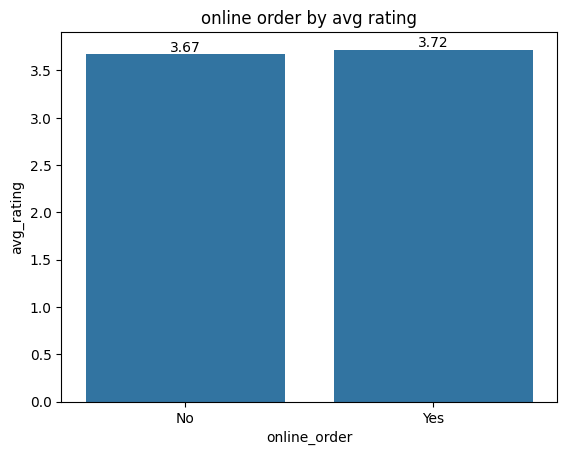

In [77]:
sns.barplot(data = online_order_rating, x='online_order',y='avg_rating')
for i, v in enumerate(online_order_rating['avg_rating']):
    plt.text(i, v, str(v), ha='center', va='bottom')
    plt.title('online order by avg rating')
plt.show()

In [78]:
# Question 2: Table booking vs rating
# Question:
# Do restaurants with table booking have higher ratings?
# Expected output: book_table | total_restaurants | avg_rating | avg_cost
# Visual:
# Bar chart: book_table vs avg_rating

In [79]:
book_table_ratings=(
    df.groupby('book_table')
    .agg(total_restaurants=('name','count'),
         avg_rating=('rate','mean'),
         avg_cost=('approx_cost(for two people)','mean'))
    .round(1)
    .reset_index()
)
book_table_ratings

,book_table,total_restaurants,avg_rating,avg_cost
0,No,45268,3.6,453.4
1,Yes,6449,4.1,1271.3


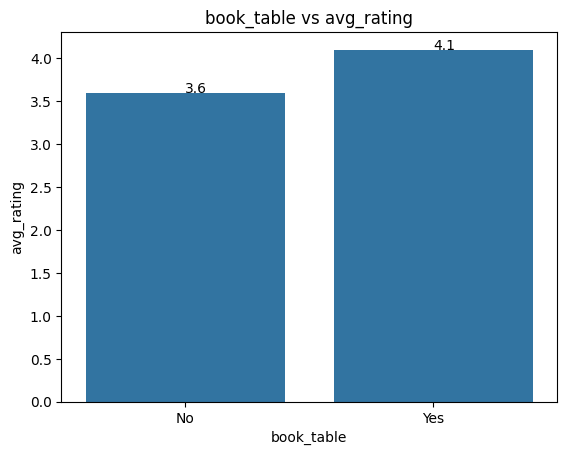

In [80]:
sns.barplot(data=book_table_ratings, x='book_table',y='avg_rating')
for i,v in enumerate(book_table_ratings['avg_rating']):
    plt.text(i,v,str(v))
plt.title('book_table vs avg_rating')
plt.show()

In [81]:
x=df.groupby('book_table')[['name']].count().sort_values(by='name',ascending=False).reset_index()
x.rename(columns={'name':'total_rest'},inplace=True)
x

,book_table,total_rest
0,No,45268
1,Yes,6449


In [82]:
df.groupby('book_table')[['rate']].mean().round(1).sort_values(by='rate',ascending=False).reset_index()

,book_table,rate
0,Yes,4.1
1,No,3.6


In [83]:
# Cost distribution
# Question:
# How is restaurant cost distributed? Are most restaurants cheap, mid-range, or expensive?
# Use column:
# 'approx_cost(for two people)'

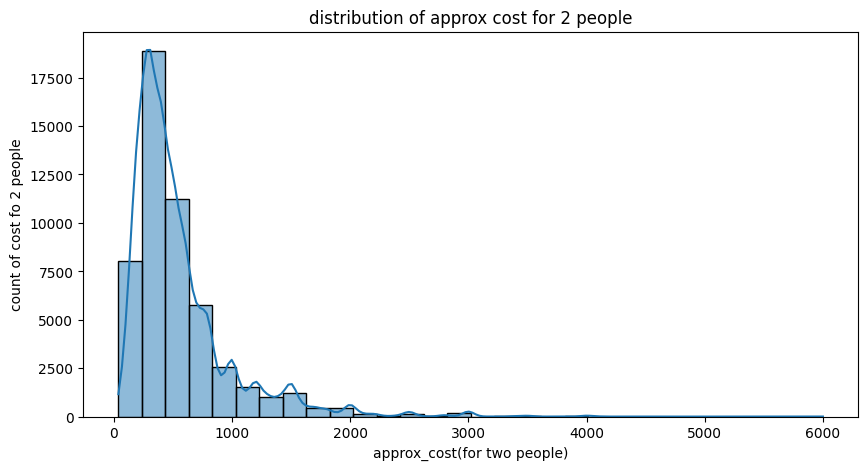

In [84]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='approx_cost(for two people)',kde=True,bins=30)
plt.title("distribution of approx cost for 2 people")
plt.ylabel('count of cost fo 2 people')
plt.show()

In [85]:
# Top 10 cuisines by restaurant count
# Question:
# Which cuisines are most commonly available?
# Expected output:
# cuisines | total_restaurants

In [86]:
df.head(2)

,name,online_order,book_table,rate,votes,contact,location,rest_type,dish_liked,cuisines,approx_cost(for two people)
0,Jalsa,Yes,Yes,4.1,775,080 42297555\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0
1,Spice Elephant,Yes,No,4.1,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0


In [87]:
top_10_cuisines= df.groupby('cuisines')[['name']].count().sort_values(by='name',ascending=False).head(10).reset_index()
top_10_cuisines.rename(columns={'name':'total_restaurants'},inplace=True)
top_10_cuisines

,cuisines,total_restaurants
0,North Indian,2913
1,"North Indian, Chinese",2385
2,South Indian,1828
3,Biryani,918
4,"Bakery, Desserts",911
5,Fast Food,803
6,Desserts,766
7,Cafe,756
8,"South Indian, North Indian, Chinese",726
9,Bakery,651


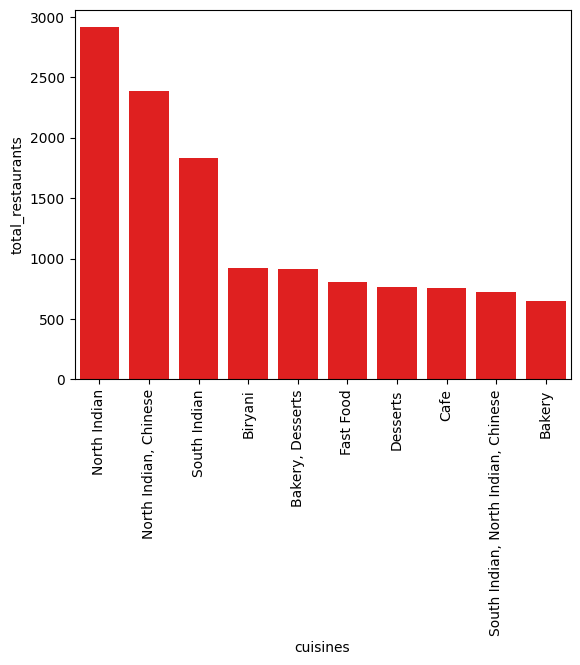

In [88]:
sns.barplot(data=top_10_cuisines, x='cuisines', y='total_restaurants',color='Red')
plt.xticks(rotation=90)
plt.show()

In [89]:
# Votes vs rating relationship
# Question:
# Do restaurants with more votes usually have higher ratings?
# Visual:
# Scatter plot: votes vs rate

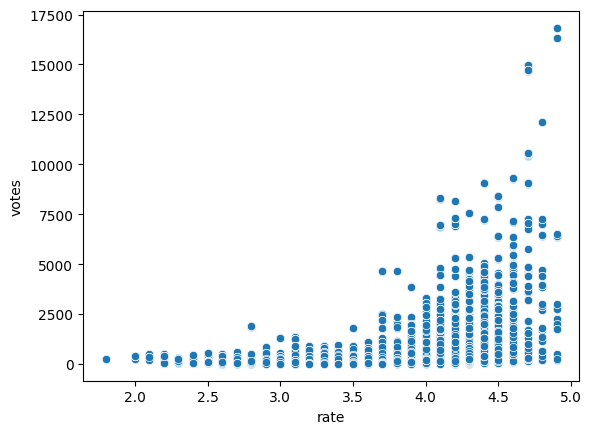

In [90]:
sns.scatterplot(data=df, x='rate',y='votes')
plt.show()

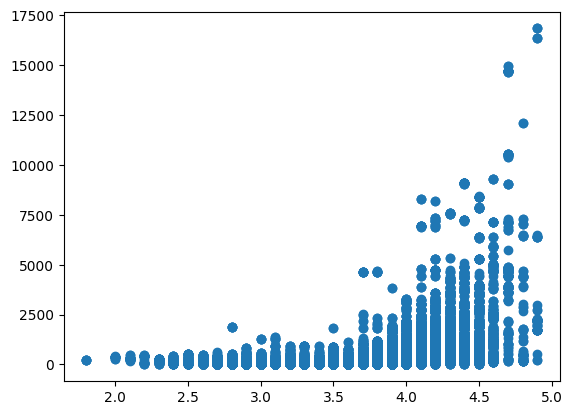

In [91]:
plt.scatter(df['rate'],df['votes'])
plt.show()

In [92]:
# Most expensive restaurant types
# Question:
# Which restaurant types have the highest average cost?
# Expected output:
# rest_type | total_restaurants | avg_cost
# Condition:
# Only include rest_type with more than 50 restaurants

In [93]:
df.head(2)

,name,online_order,book_table,rate,votes,contact,location,rest_type,dish_liked,cuisines,approx_cost(for two people)
0,Jalsa,Yes,Yes,4.1,775,080 42297555\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0
1,Spice Elephant,Yes,No,4.1,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0


In [94]:
expensive_rest_type= (
    df.groupby('rest_type')
.agg(
        total_restaurants=('name','count'),
        avg_cost =('approx_cost(for two people)','mean')
     )
.round(2)
.query('total_restaurants > 50')
.sort_values(by ='avg_cost',ascending=False)
.reset_index()
.head(11)
)
expensive_rest_type


,rest_type,total_restaurants,avg_cost
0,Fine Dining,346,2707.51
1,"Pub, Microbrewery",84,1776.19
2,Lounge,396,1694.07
3,"Microbrewery, Casual Dining",132,1658.33
4,"Bar, Casual Dining",425,1337.53
5,"Casual Dining, Pub",127,1320.47
6,"Casual Dining, Microbrewery",59,1314.58
7,"Pub, Casual Dining",255,1261.18
8,Bar,697,1256.18
9,Pub,357,1242.58


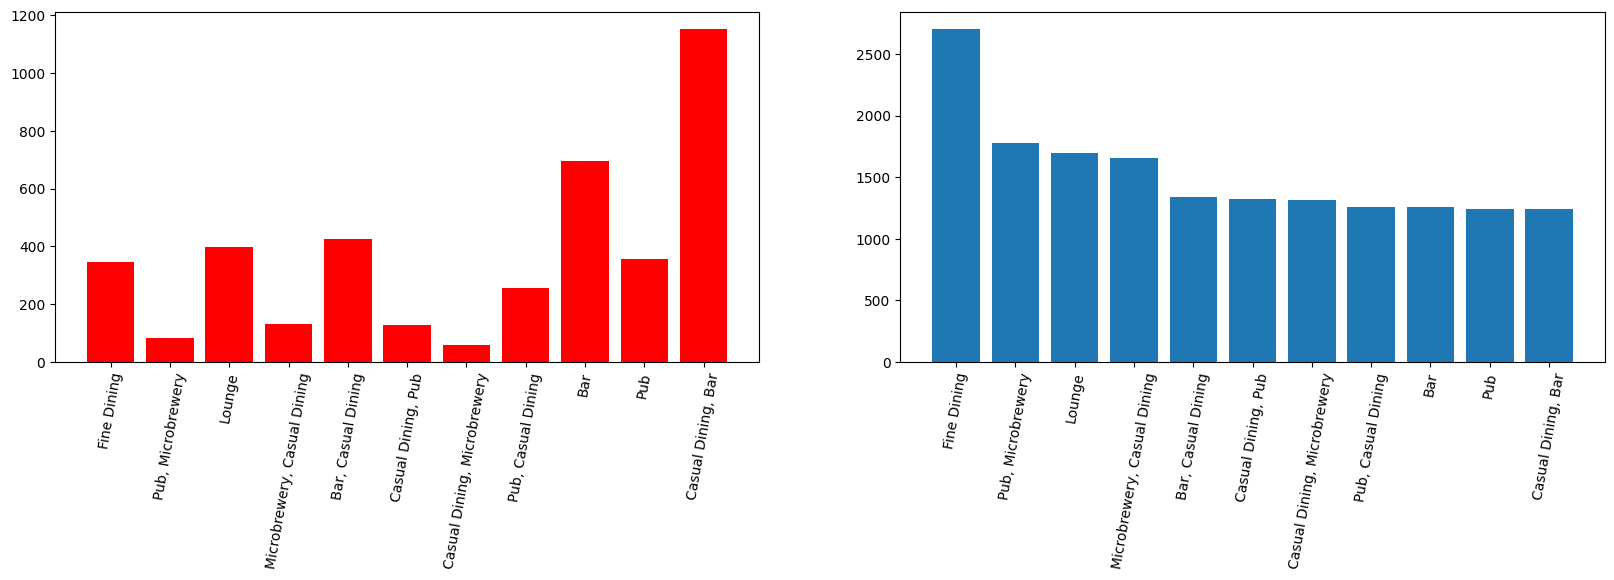

In [95]:
fig = plt.figure(figsize=(20,10))
ax1 = fig.add_subplot(2,2,1)
ax1.bar(expensive_rest_type['rest_type'],expensive_rest_type['total_restaurants'],color="red")
ax1.tick_params(axis='x', rotation=80)

ax2= fig.add_subplot(2,2,2)
ax2.bar(expensive_rest_type['rest_type'],expensive_rest_type['avg_cost'])
ax2.tick_params(axis='x', rotation=80)


In [ ]:
# Top 10 locations by total votes
# Find which locations have the highest total customer engagement based on votes.
# Expected output:
# location | total_restaurants | total_votes | avg_rating
# Condition:
# Only include locations with more than 100 restaurants

In [96]:
df.head(2)

,name,online_order,book_table,rate,votes,contact,location,rest_type,dish_liked,cuisines,approx_cost(for two people)
0,Jalsa,Yes,Yes,4.1,775,080 42297555\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0
1,Spice Elephant,Yes,No,4.1,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0


In [110]:
top_10_rest_location= (
    df.groupby('location')
.agg(total_restaurants =('name','count'), 
     total_votes = ('votes','count'),
     avg_rating=('rate','mean'))
.round(1)
.query('total_restaurants > 100')
.sort_values(by='total_restaurants', ascending=False)
.head(10)
.reset_index()
)

top_10_rest_location

,location,total_restaurants,total_votes,avg_rating
0,BTM,5124,5124,3.6
1,HSR,2523,2523,3.7
2,Koramangala 5th Block,2504,2504,4.0
3,JP Nagar,2235,2235,3.7
4,Whitefield,2144,2144,3.6
5,Indiranagar,2083,2083,3.8
6,Jayanagar,1926,1926,3.8
7,Marathahalli,1846,1846,3.6
8,Bannerghatta Road,1630,1630,3.6
9,Bellandur,1286,1286,3.6


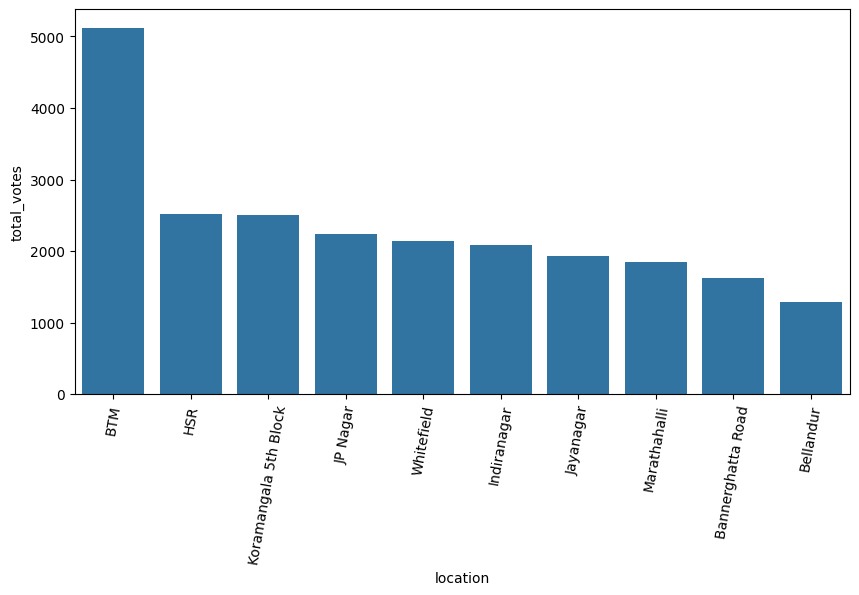

In [113]:
plt.figure(figsize=(10,5))
sns.barplot(data = top_10_rest_location, x='location',y='total_votes')
plt.xticks(rotation=80)
plt.show()

In [114]:
# Question 1: Create cost category and analyze rating
# Create a new column called cost_category:
# Low Cost      <= 300
# Medium Cost   301 to 700
# High Cost     701 to 1500
# Premium       > 1500

# Then find average rating and total restaurants in each cost category.
# Expected output:
# cost_category | total_restaurants | avg_rating | avg_votes

In [115]:
def cost_category(cost):
    if cost <= 300:
        return 'low cost'
    elif cost > 300 and cost <= 700:
        return 'medium cost'
    elif cost > 700 and cost <= 1500:
        return 'high cost'
    else:
        return 'premium'

In [116]:
df['cost_category'] = df['approx_cost(for two people)'].apply(cost_category)
# Take every value from approx_cost(for two people), send it into the cost_category()
# function, get the category result, and store that result in a new column called cost_category

In [117]:
df.head(2)

,name,online_order,book_table,rate,votes,contact,location,rest_type,dish_liked,cuisines,approx_cost(for two people),cost_category
0,Jalsa,Yes,Yes,4.1,775,080 42297555\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,high cost
1,Spice Elephant,Yes,No,4.1,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,high cost


In [120]:
top_cost_cat = (
    df.groupby('cost_category')
    .agg(total_restauarnts = ('name','count'),
         avg_rating=('rate','mean'),
         avg_votes = ('votes','mean'))
    .round(0)
    .sort_values(by='total_restauarnts',ascending=False)
    .reset_index()
    
)
top_cost_cat

,cost_category,total_restauarnts,avg_rating,avg_votes
0,medium cost,22275,4.0,189.0
1,low cost,18554,4.0,50.0
2,high cost,9109,4.0,805.0
3,premium,1779,4.0,1245.0


In [126]:
x=(
    df[(df['rate']==4.3) & (df['approx_cost(for two people)'] <= 500) & (df['votes'] >= 100)]
[['name','location', 'rate', 'votes', 'approx_cost(for two people)']].sort_values(by='rate',ascending=False).head(10)
)
x

,name,location,rate,votes,approx_cost(for two people)
52,Corner House Ice Cream,Banashankari,4.3,345,400.0
32565,Tall Blonde French,Koramangala 5th Block,4.3,726,400.0
33358,The ThickShake Factory,Koramangala 7th Block,4.3,236,350.0
33351,Joses Mess,BTM,4.3,317,300.0
33347,Art of Delight,Koramangala 5th Block,4.3,450,400.0
33345,Khawa Karpo,Koramangala 5th Block,4.3,995,350.0
33210,Zero Kelvin,Koramangala 4th Block,4.3,169,450.0
33204,Berryd Alive,Koramangala 5th Block,4.3,1902,400.0
32861,Chai Galli,Koramangala 5th Block,4.3,480,450.0
32622,Snowora,Koramangala 4th Block,4.3,343,450.0
